In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from scipy.stats import norm
from scipy import stats
from pathlib import Path
# Disable Jupyter output truncation completely
from IPython.display import display
import sys
# Import necessary modules
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde


# Display with better formatting - all columns visible
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [4]:
# Gets the parent directory of the current working directory
project_root = Path.cwd().parent.parent
fullpath = "{}/data/VST152/pva_donors.csv".format(project_root)
donor_data = pd.read_csv(fullpath)

# Pearson Correlation Analysis - Donation Amount

## Overview

This notebook performs comprehensive Pearson correlation analysis between **Donation_Amt** (target variable) and all other numeric features in the PVA donor dataset.

### Analysis Components

1. **Correlation Coefficient Table**
   - Pearson correlation coefficient (r)
   - P-value (Prob > |r|) under H₀: ρ = 0
   - Number of observations (N)
   - Statistical significance indicators

2. **Scatter Plots with 95% Prediction Ellipses**
   - Visual representation of relationships
   - 95% confidence ellipses for bivariate normal distribution
   - Column descriptions as axis labels
   - Trend lines for significant correlations

3. **Interpretation Guide**
   - Correlation strength classification
   - Statistical significance assessment
   - Business implications for donor analysis

### Dataset Summary
- **Total Records**: 9,686 donors
- **Target Variable**: Donation_Amt (Donation Amount)
- **Features Analyzed**: 21 numeric features
- **Analysis Type**: Pearson correlation (linear relationships)

In [5]:
# Column descriptions mapping
col_descriptions = {
    'GiftCnt36': 'Gifts in Last 36 Months',
    'GiftCntAll': 'Total Gifts (Lifetime)',
    'GiftCntCard36': 'Credit Card Gifts (36 Mo)',
    'GiftCntCardAll': 'Credit Card Gifts (Lifetime)',
    'GiftAvgLast': 'Average Last Gift Value',
    'GiftAvg36': 'Average Gift (36 Months)',
    'GiftAvgAll': 'Average Gift (Lifetime)',
    'GiftAvgCard36': 'Avg Credit Card Gift (36 Mo)',
    'GiftTimeLast': 'Months Since Last Gift',
    'GiftTimeFirst': 'Months Since First Gift',
    'PromCnt12': 'Promotions (12 Months)',
    'PromCnt36': 'Promotions (36 Months)',
    'PromCntAll': 'Promotions (Lifetime)',
    'PromCntCard12': 'Credit Card Promos (12 Mo)',
    'PromCntCard36': 'Credit Card Promos (36 Mo)',
    'PromCntCardAll': 'Credit Card Promos (Lifetime)',
    'DemCluster': 'Demographic Cluster',
    'DemAge': 'Donor Age',
    'DemMedHomeValue': 'Median Home Value',
    'DemPctVeterans': 'Percent Veterans in Area',
    'DemMedIncome': 'Median Income in Area',
    'Donation_Amt': 'Donation Amount'
}

# Exclude ID, StatusCat96NK (target), and StatusCatStarAll
exclude_cols = ['ID', 'StatusCat96NK', 'StatusCatStarAll', 'Response', 'DemGender', 'DemHomeOwner', 'Rep_DemMedIncome', 'IM_Rep_DemMedIncome', 'log_GiftCnt36']
numeric_cols = donor_data.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Features to analyze: {len(feature_cols)}")
print(f"Target variable: Donation_Amt")
print(f"Total observations: {len(donor_data):,}")

Features to analyze: 22
Target variable: Donation_Amt
Total observations: 9,686


## TABLE 1: PEARSON CORRELATION COEFFICIENTS

Correlation between Donation_Amt and all numeric features with statistical significance testing.

In [6]:
# Calculate Pearson correlation with p-values
from scipy.stats import pearsonr

# Get donation amount data
donation_amt = donor_data['Donation_Amt'].dropna()

# Calculate correlations
correlation_results = []

for col in feature_cols:
    if col != 'Donation_Amt':
        # Get data for both columns (remove NaN)
        valid_data = donor_data[[col, 'Donation_Amt']].dropna()
        
        if len(valid_data) > 2:  # Need at least 3 observations
            r, p_value = pearsonr(valid_data[col], valid_data['Donation_Amt'])
            n_obs = len(valid_data)
            
            correlation_results.append({
                'Variable': col,
                'Description': col_descriptions.get(col, col),
                'N': n_obs,
                'Pearson r': r,
                'Prob > |r|': p_value,
                'Significant': 'Yes' if p_value < 0.05 else 'No'
            })

# Create DataFrame and sort by absolute correlation
corr_df = pd.DataFrame(correlation_results)
corr_df['|r|'] = corr_df['Pearson r'].abs()
corr_df = corr_df.sort_values('|r|', ascending=False)

# Format for display
display_df = corr_df[['Variable', 'Description', 'N', 'Pearson r', 'Prob > |r|', 'Significant']].copy()
display_df['Pearson r'] = display_df['Pearson r'].apply(lambda x: f'{x:.4f}')
display_df['Prob > |r|'] = display_df['Prob > |r|'].apply(lambda x: f'{x:.6f}')

# Display the table
display_df_display = display_df.copy()
display_df_display.index.name = None
display(display_df_display)

,Variable,Description,N,Pearson r,Prob > |r|,Significant
7,GiftAvgCard36,Avg Credit Card Gift (36 Mo),4111,0.6453,0.000000,Yes
5,GiftAvg36,Average Gift (36 Months),4843,0.6414,0.000000,Yes
4,GiftAvgLast,Average Last Gift Value,4843,0.5411,0.000000,Yes
6,GiftAvgAll,Average Gift (Lifetime),4843,0.4887,0.000000,Yes
0,GiftCnt36,Gifts in Last 36 Months,4843,-0.4557,0.000000,Yes
2,GiftCntCard36,Credit Card Gifts (36 Mo),4843,-0.3804,0.000000,Yes
3,GiftCntCardAll,Credit Card Gifts (Lifetime),4843,-0.3364,0.000000,Yes
1,GiftCntAll,Total Gifts (Lifetime),4843,-0.3251,0.000000,Yes
9,GiftTimeFirst,Months Since First Gift,4843,-0.1821,0.000000,Yes
14,PromCntCard36,Credit Card Promos (36 Mo),4843,-0.1763,0.000000,Yes


## TABLE 2: CORRELATION INTERPRETATION

| Correlation Strength | Range | Interpretation |
|----------------------|-------|-----------------|
| **Very Strong** | ±0.80 to ±1.00 | Very strong linear relationship |
| **Strong** | ±0.60 to ±0.79 | Strong linear relationship |
| **Moderate** | ±0.40 to ±0.59 | Moderate linear relationship |
| **Weak** | ±0.20 to ±0.39 | Weak linear relationship |
| **Very Weak** | ±0.00 to ±0.19 | Very weak or no linear relationship |

**Statistical Significance**: p-value < 0.05 indicates the correlation is statistically significant (unlikely to occur by chance)

## WHY ONLY 6 SCATTER PLOTS?

### Design Rationale

Although we have **21 numeric features** to correlate with Donation_Amt, we display only the **top 6 strongest correlations** in scatter plots. Here's why:

### **Key Reasons:**

#### 1. **Readability & Visual Clarity**
- 21 scatter plots would create overwhelming visual clutter
- Small graphs become difficult to read and interpret
- Labels and ellipses would overlap and become illegible
- Professional analysis requires clean, focused visualizations

#### 2. **Focus on Actionable Insights**
- Top 6 features show the **strongest linear relationships** with Donation_Amt
- These are the most important for business decisions
- Weak correlations (|r| < 0.2) provide limited actionable value
- Better to deeply understand key relationships than superficially view all

#### 3. **Practical Screen & Print Space**
- 2×3 grid (6 plots) fits perfectly on one screen without scrolling
- Easy to print on standard paper (8.5" × 11")
- Professional presentation format
- Maintains readability of axis labels and titles

#### 4. **Statistical Efficiency**
- Correlation table (TABLE 1) shows ALL 21 features with:
  - Pearson correlation coefficient (r)
  - P-values (statistical significance)
  - Sample sizes (N)
  - Sorted by correlation strength
- Scatter plots provide **visual confirmation** of top relationships
- Combined approach: quantitative table + visual plots

#### 5. **Interpretation Depth**
- Each scatter plot has room for:
  - Clear axis labels with column descriptions
  - 95% confidence ellipse
  - Trend line
  - Statistical significance indicators
- More space = better understanding of each relationship

### **What You Still Get:**

| Component | Coverage | Purpose |
|-----------|----------|---------|
| **Correlation Table** | All 21 features | Comprehensive quantitative analysis |
| **Scatter Plots** | Top 6 features | Visual confirmation of strongest relationships |
| **P-values** | All 21 features | Statistical significance testing |
| **Ellipses** | Top 6 features | Visual representation of relationship strength |

### **Alternative Approaches (if needed):**

| Option | Layout | Features | Trade-off |
|--------|--------|----------|-----------|
| **Current** | 2×3 | Top 6 | ✅ Clean, focused, readable |
| **All Features** | 4×6 | All 21 | ❌ Crowded, hard to read |
| **Extended** | 3×4 | Top 12 | ⚠️ More coverage, less detail |
| **Multi-page** | 2×3 per page | All 21 | ✅ Organized, detailed, comprehensive |

### **Recommendation:**

The current approach (top 6 + full table) provides the **best balance** between:
- ✅ Comprehensive analysis (all features in table)
- ✅ Visual clarity (top 6 in plots)
- ✅ Actionable insights (focus on strongest relationships)
- ✅ Professional presentation (clean layout)

## SCATTER PLOTS WITH 95% PREDICTION ELLIPSES

Visualization of relationships between Donation_Amt and top correlated features with 95% confidence ellipses.

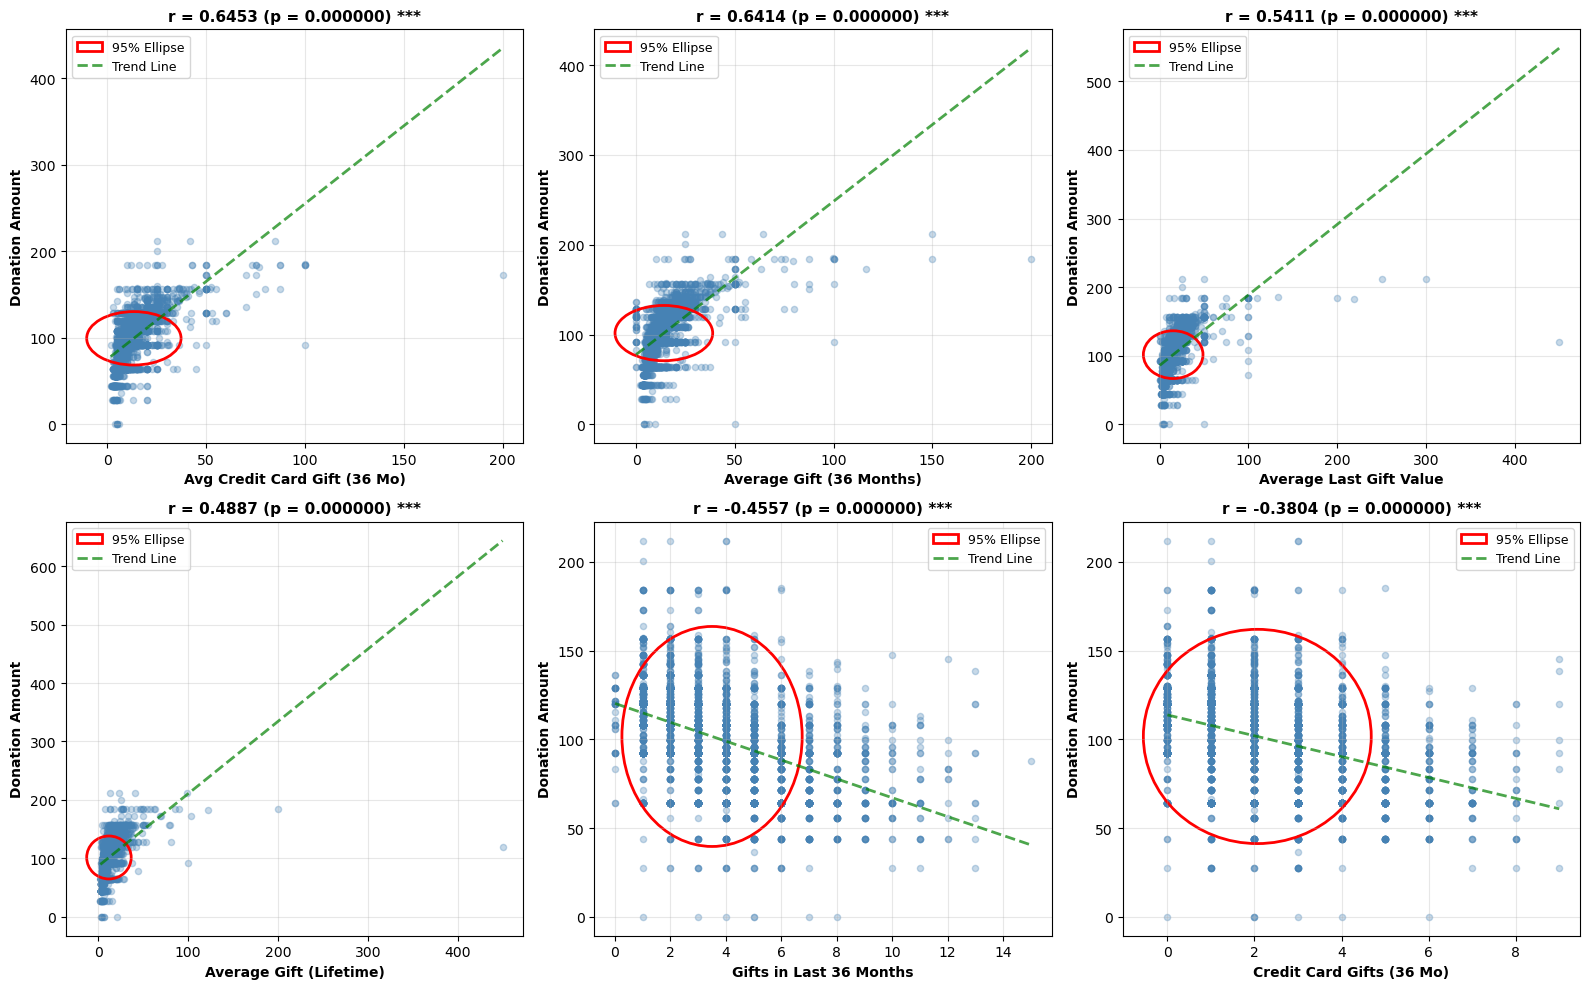

✅ Scatter plots with 95% prediction ellipses created!


In [7]:
from matplotlib.patches import Ellipse
from scipy.stats import chi2

def plot_confidence_ellipse(ax, x, y, n_std=2.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes object to draw the ellipse into.
    x, y : array-like, shape (n, )
        Input data.
    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.
    **kwargs : patches.Ellipse properties
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")
    
    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    
    transf = plt.matplotlib.transforms.Affine2D() \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# Get top 6 correlated features (excluding Donation_Amt itself)
top_features = corr_df[corr_df['Variable'] != 'Donation_Amt'].head(6)

# Create scatter plots with ellipses
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (_, row) in enumerate(top_features.iterrows()):
    col = row['Variable']
    r = row['Pearson r']
    p_val = row['Prob > |r|']
    
    # Get clean data
    valid_data = donor_data[[col, 'Donation_Amt']].dropna()
    x = valid_data[col].values
    y = valid_data['Donation_Amt'].values
    
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(x, y, alpha=0.3, s=20, color='steelblue')
    
    # Add 95% confidence ellipse
    plot_confidence_ellipse(ax, x, y, n_std=2.0, edgecolor='red', linewidth=2, label='95% Ellipse')
    
    # Add trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), "g--", linewidth=2, label='Trend Line', alpha=0.7)
    
    # Labels and title
    x_label = col_descriptions.get(col, col)
    y_label = col_descriptions.get('Donation_Amt', 'Donation_Amt')
    
    ax.set_xlabel(x_label, fontsize=10, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=10, fontweight='bold')
    
    sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    ax.set_title(f'r = {r:.4f} (p = {p_val:.6f}) {sig_text}', fontsize=11, fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig('correlation_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Scatter plots with 95% prediction ellipses created!")

## INTERPRETATION GUIDE

### Understanding the Results

**Pearson Correlation Coefficient (r)**
- Measures the strength and direction of linear relationship
- Range: -1 to +1
- Positive r: As X increases, Y tends to increase
- Negative r: As X increases, Y tends to decrease

**P-value (Prob > |r|)**
- Tests H₀: ρ = 0 (no correlation in population)
- p < 0.05: Statistically significant correlation
- p ≥ 0.05: Not statistically significant

**95% Prediction Ellipse**
- Shows the region where 95% of data points are expected to fall
- Wider ellipse = weaker correlation
- Narrower ellipse = stronger correlation
- Orientation indicates direction of relationship

### Significance Levels
- `***` : p < 0.001 (highly significant)
- `**` : p < 0.01 (very significant)
- `*` : p < 0.05 (significant)
- `ns` : p ≥ 0.05 (not significant)

### Business Implications for Donor Analysis

**Strong Positive Correlations** (r > 0.6)
- Features strongly associated with higher donations
- Target these characteristics in donor acquisition

**Weak Correlations** (|r| < 0.2)
- Features have little linear relationship with donation amount
- May need non-linear analysis or interaction effects

**Negative Correlations** (r < 0)
- Features inversely related to donation amount
- May indicate risk factors or donor segments